In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path = '/content/drive/My Drive/datasets/CMOS/32nm/NOT/simu_0/treated_data.txt'

Mounted at /content/drive


CNN works better on images, data that have spacial relations. But it usually is not good in tabular data

# INVERTER CIRCUIT 32nm bulk CMOS

> Path: Electrical-Behaviour-Prediction/CMOS/32nm/NOT/Models/simu0/Advanced_Algorithms.ipynb

> https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction/tree/main/CMOS

## Obs

I'm using simu_0/treated_data dataset in this analysis

Joined_data.csv: contém os resultados brutos das simulações elétricas feitas no hspice (Monte Carlo).

Treated_data.csv: contém widths, tensões e temperaturas mapeadas.

O notebook advanced_algotithms usa o joined_data e depois gera o treated_data;

No entanto, ainda não descobri a diferença entre simulação0 e simulação1. Estou usando a simul0

## Dataset

Inputs
x  = [nmos@var, pmos@var, temper, voltage, width_nmos, width_pmos, length]

Outputs
y = [tphl, tplh, iint]

Variables

- **nmos@var**: variação de processo do transistor NMOS
- **pmos@var**: variação de processo do transistor PMOS
- **tphl**:	tempo de propagação da saída High -> Low
- **tplh**: tempo de propagação da saída Low -> High
- **iint**:	energia dissipada pelo circuito
- **temper**:	temperatura de operação do circuito
- **voltage**: tensão de alimentação (vdd)
- **width_pmos**:	largura W do transistor PMOS
- **width_nmos**: largura W do transistor NMOS
- **length_n&p**: comprimento do canal L dos transistores NMOS e PMOS

In [ ]:
df = pd.read_csv(path, index_col=0)
# Renaming 'tensao' to 'voltage' to keep in english
df = df.rename(columns={'tensao': 'voltage'})
df.describe()

,nmos@var,pmos@varp,tphl,tplh,iint,temper,voltage,width_pmos,width_nmos,length_n&p
count,155077.000000,155077.000000,1.550770e+05,1.550770e+05,1.550770e+05,155077.000000,155077.000000,1.550770e+05,1.550770e+05,1.550770e+05
mean,0.509108,-0.450684,6.592126e-11,-6.440956e-10,-2.063419e-03,37.467033,0.750069,2.266666e-07,8.083333e-08,3.238095e-08
std,0.016825,0.015274,7.263116e-10,2.477490e-09,2.024013e-01,42.982289,0.111693,1.234463e-07,2.531751e-08,4.477225e-09
min,0.461300,-0.493300,-3.819000e-12,-1.000000e-08,-3.342370e+01,-25.000000,0.600000,7.000000e-08,7.000000e-08,2.000000e-08
25%,0.497800,-0.461900,9.825000e-12,7.604000e-12,-2.351000e-15,0.000000,0.700000,1.400000e-07,7.000000e-08,3.200000e-08
50%,0.509000,-0.450500,1.226000e-11,1.080000e-11,-1.657000e-15,50.000000,0.800000,1.400000e-07,7.000000e-08,3.200000e-08
75%,0.520200,-0.440300,1.476000e-11,1.874000e-11,-1.336000e-15,75.000000,0.800000,3.500000e-07,7.000000e-08,3.200000e-08
max,0.586100,-0.405800,1.018000e-08,2.631000e-10,2.933300e+01,100.000000,0.900000,4.200000e-07,1.400000e-07,4.000000e-08


In [ ]:
# Checking if there're null values
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155077 entries, 0 to 167999
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   nmos@var    155077 non-null  float64
 1   pmos@varp   155077 non-null  float64
 2   tphl        155077 non-null  float64
 3   tplh        155077 non-null  float64
 4   iint        155077 non-null  float64
 5   temper      155077 non-null  float64
 6   voltage     155077 non-null  float64
 7   width_pmos  155077 non-null  float64
 8   width_nmos  155077 non-null  float64
 9   length_n&p  155077 non-null  float64
dtypes: float64(10)
memory usage: 13.0 MB


In [ ]:
# Checking if there're fixed values in variables
df.nunique()

,0
nmos@var,513
pmos@varp,489
tphl,8200
tplh,10430
iint,14040
temper,6
voltage,4
width_pmos,5
width_nmos,2
length_n&p,3


There aren't fixed variables values.

- **nmos@var**: Existem 513 valores diferentes
- **pmos@var**:	Existem 489 valores diferentes
- **tphl**:	Existem 8200 valores diferentes
- **tplh**:	Existem 10430 valores diferentes
- **iint**:	Existem 14040 valores diferentes
- **temper**:	Existem 6 temperaturas diferentes
- **voltage**:	Existem 4 tensões diferentes
- **width_pmos**:	Existem 5 larguras diferentes
- **width_nmos**:	Existem 2 larguras diferentes
- **length_n&p**: Existem 3 valores diferentes

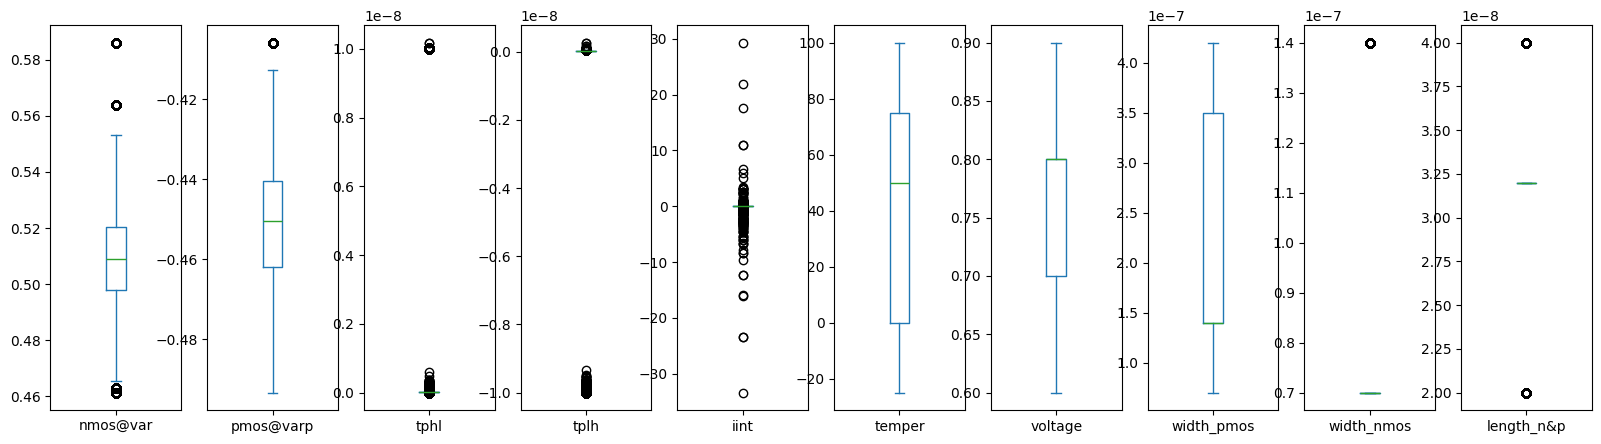

<Figure size 640x480 with 0 Axes>

In [ ]:
# Boxplot for variables characteristics (median, outliers, etc)
df.plot(kind='box',figsize=(30,5), subplots=True, layout=(1, 15))

_ = plt.figure()
plt.show()

In [ ]:
df.describe()

,nmos@var,pmos@varp,tphl,tplh,iint,temper,voltage,width_pmos,width_nmos,length_n&p
count,155077.000000,155077.000000,1.550770e+05,1.550770e+05,1.550770e+05,155077.000000,155077.000000,1.550770e+05,1.550770e+05,1.550770e+05
mean,0.509108,-0.450684,6.592126e-11,-6.440956e-10,-2.063419e-03,37.467033,0.750069,2.266666e-07,8.083333e-08,3.238095e-08
std,0.016825,0.015274,7.263116e-10,2.477490e-09,2.024013e-01,42.982289,0.111693,1.234463e-07,2.531751e-08,4.477225e-09
min,0.461300,-0.493300,-3.819000e-12,-1.000000e-08,-3.342370e+01,-25.000000,0.600000,7.000000e-08,7.000000e-08,2.000000e-08
25%,0.497800,-0.461900,9.825000e-12,7.604000e-12,-2.351000e-15,0.000000,0.700000,1.400000e-07,7.000000e-08,3.200000e-08
50%,0.509000,-0.450500,1.226000e-11,1.080000e-11,-1.657000e-15,50.000000,0.800000,1.400000e-07,7.000000e-08,3.200000e-08
75%,0.520200,-0.440300,1.476000e-11,1.874000e-11,-1.336000e-15,75.000000,0.800000,3.500000e-07,7.000000e-08,3.200000e-08
max,0.586100,-0.405800,1.018000e-08,2.631000e-10,2.933300e+01,100.000000,0.900000,4.200000e-07,1.400000e-07,4.000000e-08


Tamanho do dataset:

# Removing outliers



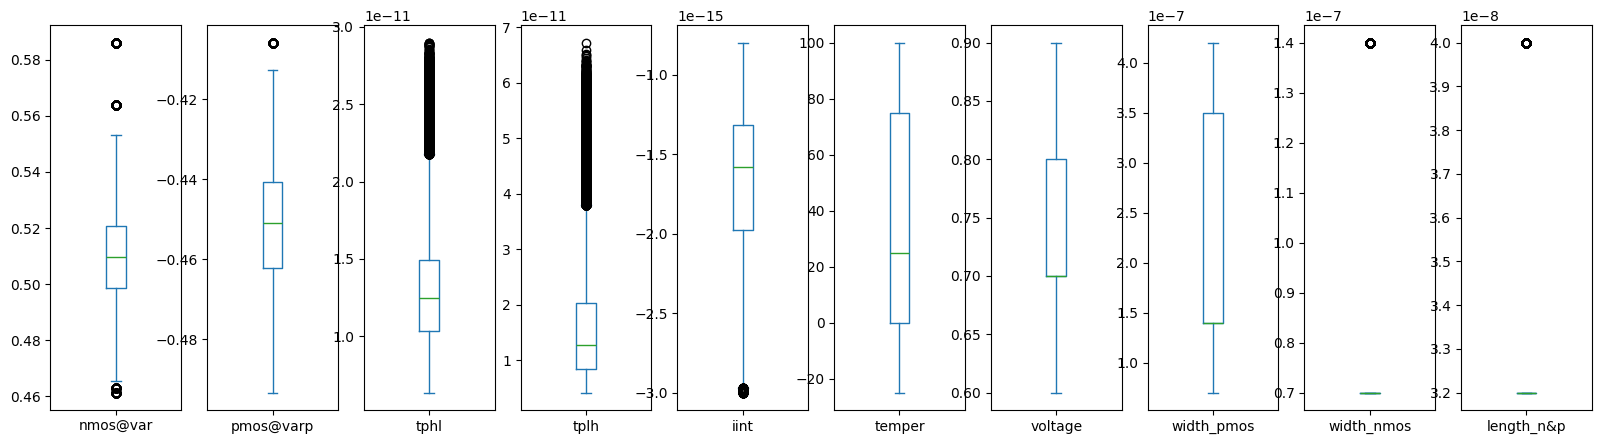

<Figure size 640x480 with 0 Axes>

In [ ]:
# Gabriel's code fot removing outliers
df = df[(2e-12<=df.tphl)&(df.tphl<=2.9e-11)]
df = df[(1e-12<=df.tplh)&(df.tplh<=6.8e-11)]
df = df[(-3e-15<=df.iint)]

df.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()

In [ ]:
df.describe()

,nmos@var,pmos@varp,tphl,tplh,iint,temper,voltage,width_pmos,width_nmos,length_n&p
count,127771.000000,127771.000000,1.277710e+05,1.277710e+05,1.277710e+05,127771.000000,127771.000000,1.277710e+05,1.277710e+05,1.277710e+05
mean,0.509723,-0.451149,1.291333e-11,1.577203e-11,-1.685973e-15,32.301735,0.749356,2.164066e-07,7.819810e-08,3.349893e-08
std,0.016645,0.015210,3.385645e-12,9.954472e-12,4.944592e-16,41.687904,0.107559,1.204728e-07,2.250916e-08,3.121656e-09
min,0.461300,-0.493300,6.351000e-12,4.125000e-12,-3.000000e-15,-25.000000,0.600000,7.000000e-08,7.000000e-08,3.200000e-08
25%,0.498500,-0.462200,1.036000e-11,8.464000e-12,-1.979000e-15,0.000000,0.700000,1.400000e-07,7.000000e-08,3.200000e-08
50%,0.509500,-0.450900,1.248000e-11,1.277000e-11,-1.579000e-15,25.000000,0.700000,1.400000e-07,7.000000e-08,3.200000e-08
75%,0.520700,-0.440600,1.492000e-11,2.024000e-11,-1.317000e-15,75.000000,0.800000,3.500000e-07,7.000000e-08,3.200000e-08
max,0.586100,-0.405800,2.898000e-11,6.720000e-11,-7.993000e-16,100.000000,0.900000,4.200000e-07,1.400000e-07,4.000000e-08


# Normalization test using MinMaxScaler


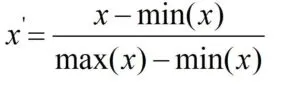

In [ ]:
from sklearn.preprocessing import MinMaxScaler
a = (df.iint-df.iint.min()) / (df.iint.max()-df.iint.min())
b = (df.tplh-df.tplh.min())/(df.tplh.max()-df.tplh.min())
c = (df.tphl-df.tphl.min())/(df.tphl.max()-df.tphl.min())

# Train, Validation, Test Sets

In [ ]:
X = df.drop(columns=['tphl', 'tplh', 'iint'])
y = df[['tphl', 'tplh', 'iint']]
print(X.shape)
print(y.shape)

(127771, 7)
(127771, 3)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

seed = 23

Xtr, Xte, ytr, yte = train_test_split(X, y, random_state=seed, test_size=0.25)

# standardscaler é mais recomendado para NN
scaler_x = StandardScaler().fit(Xtr)
scaler_y = StandardScaler().fit(ytr)

Xtr_sc = scaler_x.transform(Xtr)
Xte_sc = scaler_x.transform(Xte)
ytr_sc = scaler_y.transform(ytr)
yte_sc = scaler_y.transform(yte)

X_train, X_val, y_train, y_val = train_test_split(Xtr_sc, ytr_sc, random_state=seed, test_size=0.33)

print("Test set X", Xte.shape)
print("Test set y", yte.shape)
print("Train set X", X_train.shape)
print("Train set y", y_train.shape)
print("Validation set X", X_val.shape)
print("Validation set y", y_val.shape)

Test set X (31943, 7)
Test set y (31943, 3)
Train set X (64204, 7)
Train set y (64204, 3)
Validation set X (31624, 7)
Validation set y (31624, 3)


In [ ]:
pd.DataFrame(X_val)

,0,1,2,3,4,5,6
0,-0.241212,0.543965,-0.776585,0.468685,-1.217267,-0.363331,-0.481589
1,-0.397300,2.419507,-0.776585,-0.461136,0.526711,-0.363331,-0.481589
2,0.563244,-0.225994,-0.776585,-1.390956,0.526711,-0.363331,-0.481589
3,-1.171740,0.142533,-1.376237,1.398505,-0.635941,-0.363331,2.076458
4,-2.504495,-0.265479,-1.376237,-1.390956,1.108037,-0.363331,-0.481589
...,...,...,...,...,...,...,...
31619,-0.043100,0.741391,0.422719,0.468685,1.108037,-0.363331,-0.481589
31620,0.118992,-1.009115,-1.376237,-0.461136,1.689363,2.752310,-0.481589
31621,1.823959,-0.943307,1.022370,0.468685,-1.217267,-0.363331,-0.481589
31622,0.094979,-0.482647,-0.176933,1.398505,-1.217267,-0.363331,-0.481589


In [ ]:
X_val[1,:]

array([-0.3973005 ,  2.41950714, -0.7765849 , -0.46113575,  0.52671069,
       -0.36333111, -0.48158926])

In [ ]:
X_val.shape

(31624, 7)

In [ ]:
print(y_train[:,0])

[-1.0304887  -0.1898071   2.89545296 ... -0.33475221  0.34856042
 -1.26121764]


# Visualization

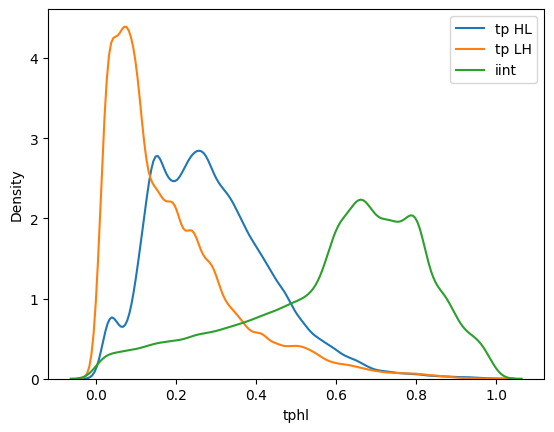

In [ ]:
sns.kdeplot(c, label = 'tp HL')
sns.kdeplot(b, label = 'tp LH')
sns.kdeplot(a, label = 'iint')
plt.legend()
plt.show()

## TPLH

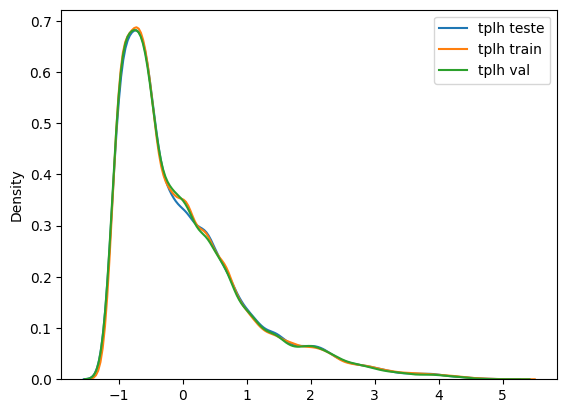

In [ ]:
#sns.kdeplot(yte.tplh, label = 'tplh teste')
#sns.kdeplot(y_train.tplh, label = 'tplh train')
#sns.kdeplot(y_val.tplh, label = 'tplh val')
#plt.legend()
#plt.show()

sns.kdeplot(yte_sc[:,1], label = 'tplh teste')
sns.kdeplot(y_train[:,1], label = 'tplh train')
sns.kdeplot(y_val[:,1], label = 'tplh val')
plt.legend()
plt.show()



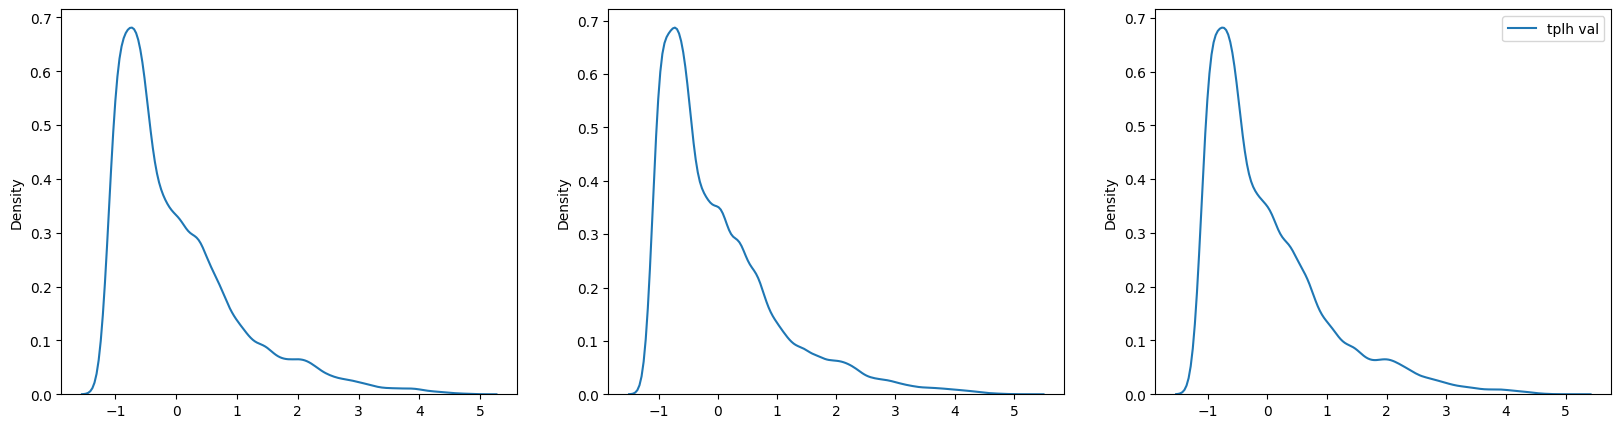

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (20,5))
sns.kdeplot(yte_sc[:,1], label = 'tplh teste', ax = ax[0])
sns.kdeplot(y_train[:,1], label = 'tplh train', ax = ax[1])
sns.kdeplot(y_val[:,1], label = 'tplh val', ax = ax[2])
plt.legend()
plt.show()

## TPHL


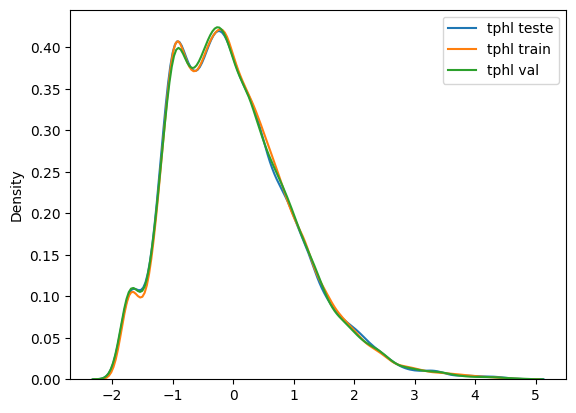

In [ ]:
sns.kdeplot(yte_sc[:,0], label = 'tphl teste')
sns.kdeplot(y_train[:,0], label = 'tphl train')
sns.kdeplot(y_val[:,0], label = 'tphl val')
plt.legend()
plt.show()

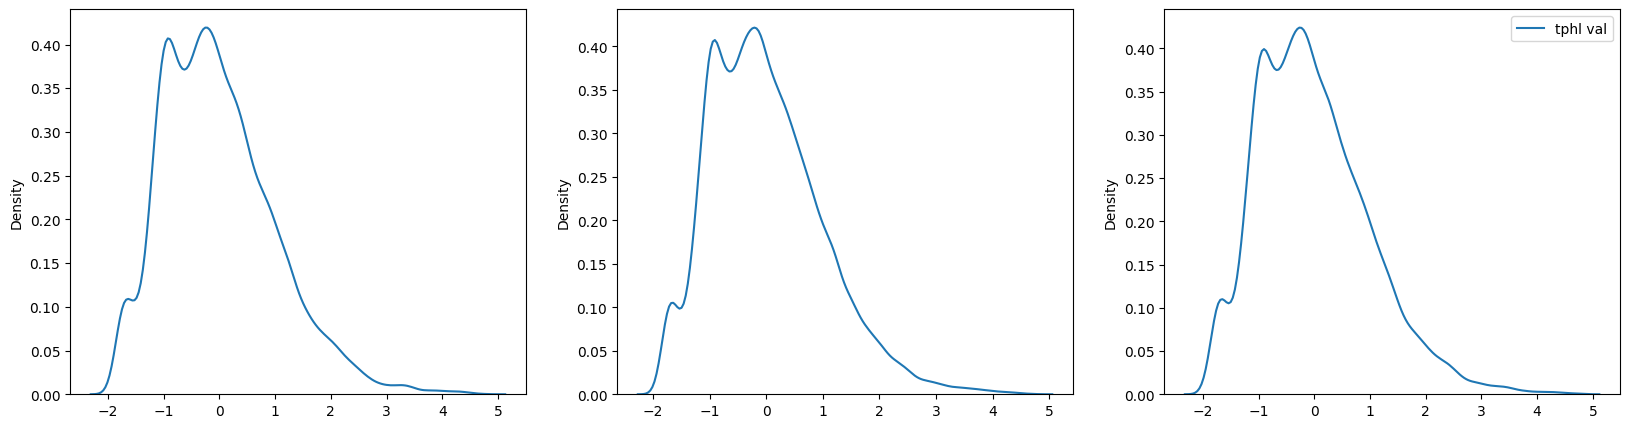

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (20,5))
sns.kdeplot(yte_sc[:,0], label = 'tphl teste', ax = ax[0])
sns.kdeplot(y_train[:,0], label = 'tphl train', ax = ax[1])
sns.kdeplot(y_val[:,0], label = 'tphl val', ax = ax[2])
plt.legend()
plt.show()

## Visualização IINT


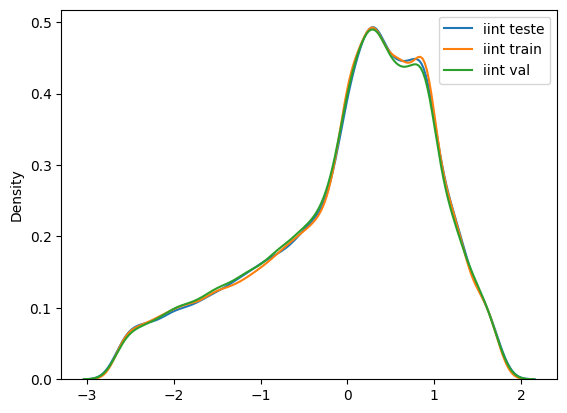

In [ ]:
sns.kdeplot(yte_sc[:,2], label = 'iint teste')
sns.kdeplot(y_train[:,2], label = 'iint train')
sns.kdeplot(y_val[:,2], label = 'iint val')
plt.legend()
plt.show()

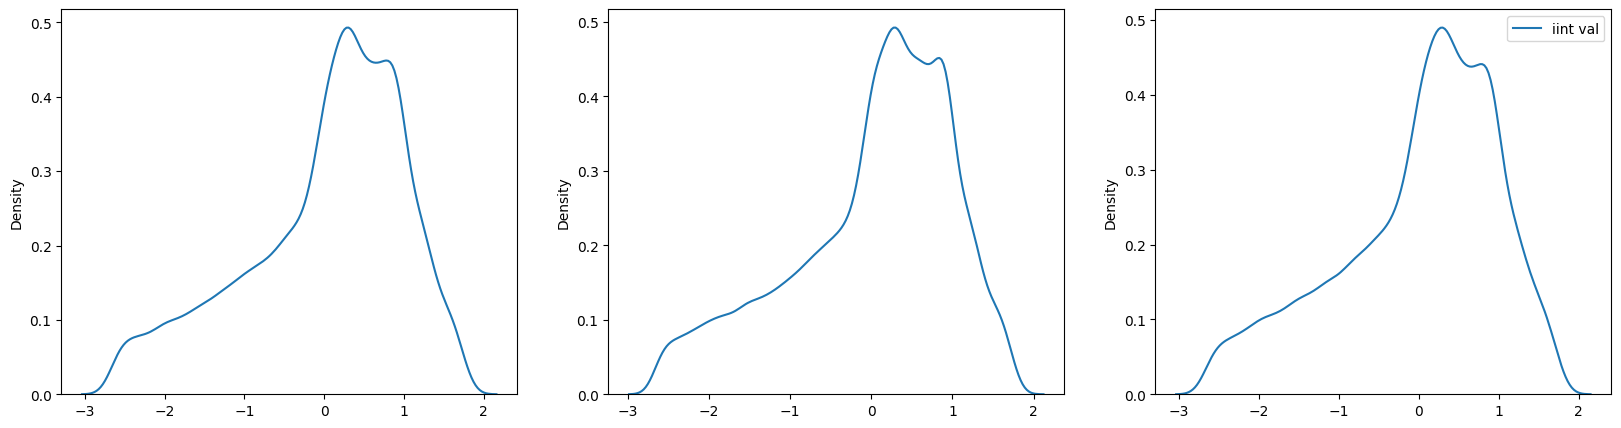

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (20,5))
sns.kdeplot(yte_sc[:,2], label = 'iint teste', ax = ax[0])
sns.kdeplot(y_train[:,2], label = 'iint train', ax = ax[1])
sns.kdeplot(y_val[:,2], label = 'iint val', ax = ax[2])
plt.legend()
plt.show()

# Multi-layer Perceptron (MPL)

Neural network for supervised learning

Idea: Testing a multilayer perceptron for regression before jumping into CNN on delay and power prediction. I'm not sure CNN is a good idea for this problem (we're using tabular data), so the idea is testing different times of ANNs.



```
Inputs
x  = [nmos@var, pmos@var, temper, voltage, width_nmos, width_pmos, length]

Outputs
y = [tphl, tplh, iint]
```



**Testing correlation between variables in the dataset**

,nmos@var,pmos@varp,tphl,tplh,iint,temper,voltage,width_pmos,width_nmos,length_n&p
0,0.5166,-0.4341,9.607000e-12,8.368000e-12,-1.330000e-15,-25.0,0.6,1.400000e-07,7.000000e-08,3.200000e-08
1,0.5064,-0.4523,9.424000e-12,8.791000e-12,-1.337000e-15,-25.0,0.6,1.400000e-07,7.000000e-08,3.200000e-08
2,0.4909,-0.4618,9.156000e-12,9.046000e-12,-1.388000e-15,-25.0,0.6,1.400000e-07,7.000000e-08,3.200000e-08
3,0.4882,-0.4667,9.111000e-12,9.161000e-12,-1.395000e-15,-25.0,0.6,1.400000e-07,7.000000e-08,3.200000e-08
4,0.5275,-0.4342,9.809000e-12,8.899000e-12,-1.351000e-15,-25.0,0.6,1.400000e-07,7.000000e-08,3.200000e-08


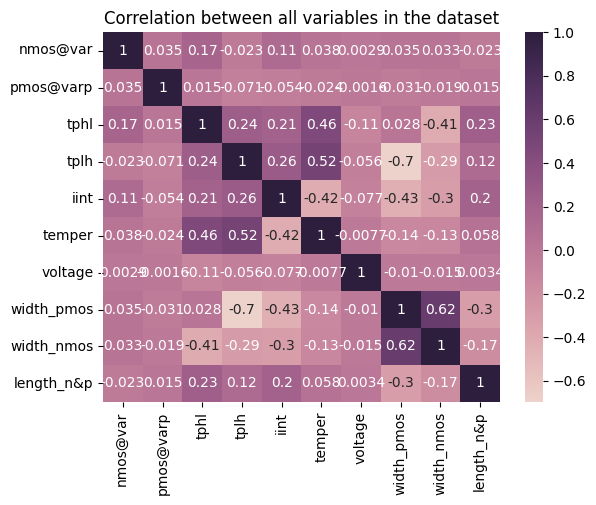

In [ ]:
ax = sns.heatmap(df.corr(numeric_only=True), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
ax.set_title('Correlation between all variables in the dataset')
ax=ax

df.head()

## Multi-layer Perceptron for Regression using Scikit-Learn

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_regressor = MLPRegressor(activation='relu',
                              solver = 'sgd',
                              hidden_layer_sizes=(100, ),
                              early_stopping = True, )



### Single-output models

#### Predicting TPHL

In [ ]:
mlp_regressor.fit(X_train, y_train[:,0])

MLPRegressor(early_stopping=True, solver='sgd')

In [ ]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.0021672358136910056


In [ ]:
y_pred = mlp_regressor.predict(X_val)

R² score (coefficient of determination) regression score function.

In [ ]:
mlp_regressor.score(X_val, y_val[:,0])

0.9957368243973294

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error
rmse = root_mean_squared_error(y_val[:, 0], y_pred)
mse = mean_squared_error(y_val[:, 0], y_pred)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MPL:, MSE {mse}')

clf: MLP, RMSE: 0.06536420748461373
clf: MPL:, MSE 0.0042724796200916335


Text(0.5, 1.0, 'MLP, TPHL')

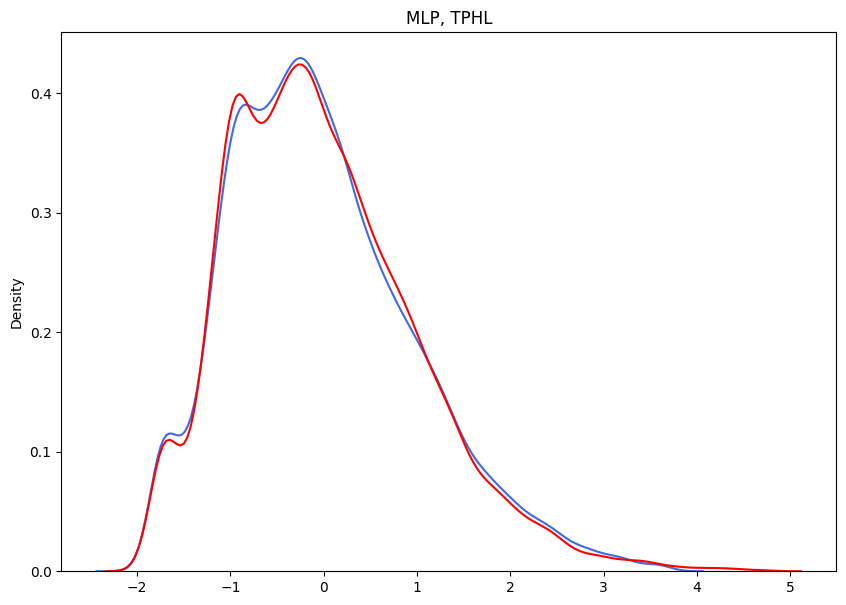

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val[:,0], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP, TPHL')

#### Predicting TPLH

In [ ]:
mlp_regressor.fit(X_train, y_train[:,1])

MLPRegressor(early_stopping=True, solver='sgd')

In [ ]:
y_pred = mlp_regressor.predict(X_val)

In [ ]:
mlp_regressor.score(X_val, y_val[:,1])

0.9964384822164103

In [ ]:
rmse = root_mean_squared_error(y_val[:, 1], y_pred)
mse = mean_squared_error(y_val[:, 1], y_pred)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE: {mse}')

clf: MLP, RMSE: 0.05914903266949426
clf: MLP, MSE: 0.0034986080657368997


Text(0.5, 1.0, 'MLP, TPLH')

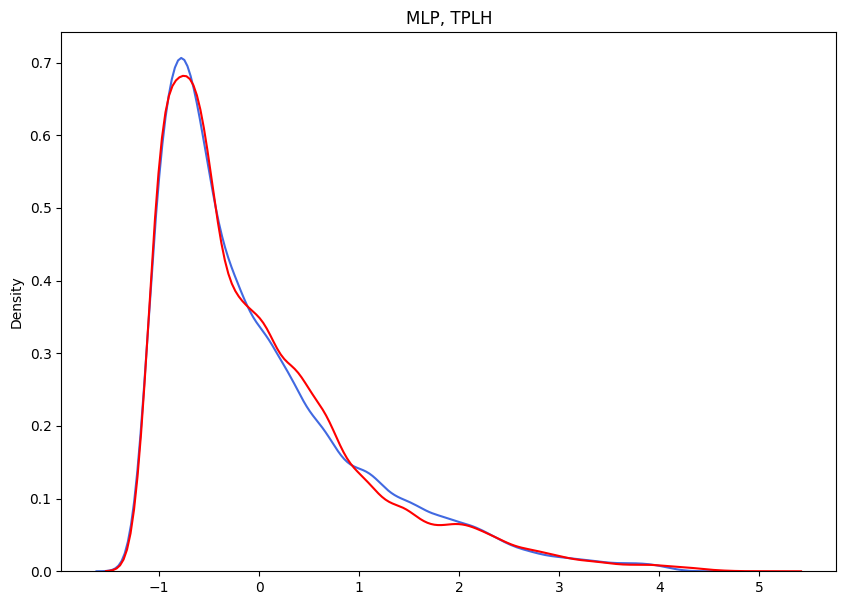

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val[:,1], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP, TPLH')

#### Predicting Energy

In [ ]:
mlp_regressor.fit(X_train, y_train[:,2])

MLPRegressor(early_stopping=True, solver='sgd')

In [ ]:
y_pred = mlp_regressor.predict(X_val)

In [ ]:
mlp_regressor.score(X_val, y_val[:,2])

0.9932249609216273

In [ ]:
rmse = root_mean_squared_error(y_val[:, 2], y_pred)
mse = mean_squared_error(y_val[:, 2], y_pred)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE: {mse}')

clf: MLP, RMSE: 0.08227366615999086
clf: MLP, MSE: 0.006768956143405625


Text(0.5, 1.0, 'MLP, TPHL')

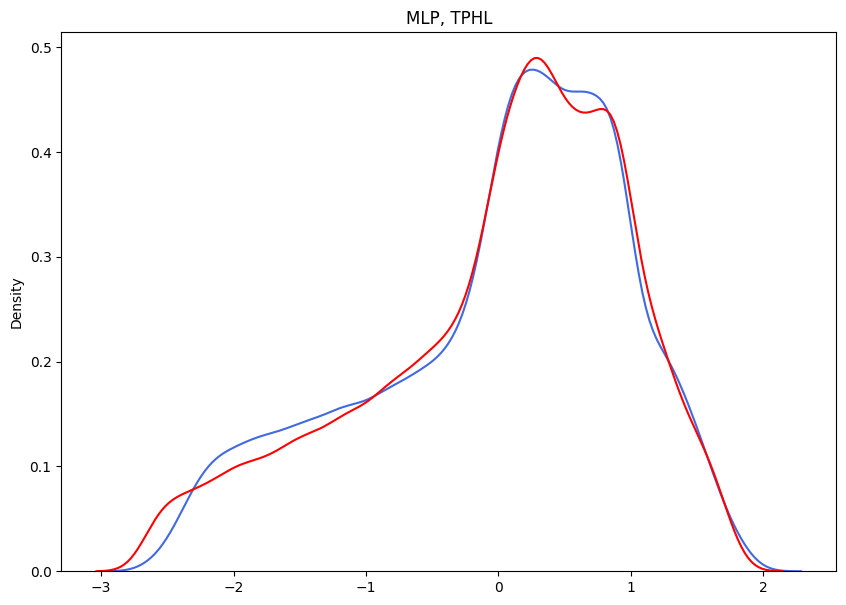

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val[:,2], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP, TPHL')

#### Results

In [ ]:
metrics_data = {
    'tphl': {'R2': 0.9958182206032986, 'RMSE': 0.06473720548370802},
    'tplh': {'R2': 0.9964413722857427, 'RMSE': 0.05912502892880983},
    'iint': {'R2': 0.9927983637222068, 'RMSE': 0.0848243498334249},
}

metrics_df = pd.DataFrame(metrics_data)

print("Metrics Table:")
print(metrics_df)

Metrics Table:
          tphl      tplh      iint
R2    0.995818  0.996441  0.992798
RMSE  0.064737  0.059125  0.084824


### Multi-output model
Predicting three outputs (multivariable regression)

In [ ]:
mlp_regressor.fit(X_train, y_train)

MLPRegressor(early_stopping=True, solver='sgd')

In [ ]:
y_pred = mlp_regressor.predict(X_val)

In [ ]:
mlp_regressor.score(X_val, y_val)

0.9946889412713807

In [ ]:
rmse = root_mean_squared_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE: {mse}')

clf: MLP, RMSE: 0.07205638377100067
clf: MLP, MSE: 0.005285070132514932


## Multi-layer Perceptron for Regression using Keras

### Single-output models

#### Predicting TPHL

In [ ]:
import tensorflow as tf
from tensorflow import keras

model = tf.keras.models.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)

])

model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train, y_train[:,0], epochs=20, validation_data=(X_val, y_val[:,0]))




Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2007/2007 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1289 - val_loss: 0.0373
Epoch 2/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0262 - val_loss: 0.0170
Epoch 3/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0126 - val_loss: 0.0090
Epoch 4/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0073 - val_loss: 0.0060
Epoch 5/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0054 - val_loss: 0.0047
Epoch 6/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0044 - val_loss: 0.0039
Epoch 7/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 8/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0032 - val_loss: 0.0029
Epoch 9/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 10/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 11/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 12/20
2007/2007 ━━━━━━━━━━━━━━━━━━

In [ ]:
ypred = model.predict(X_val)
mse = mean_squared_error(y_val[:,0], ypred)
rmse = root_mean_squared_error(y_val[:,0], ypred)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
clf: ANN, rmse: 0.03454722905367985
clf: ANN, mse: 0.0011935110352874212


#### Predicting TPLH

In [ ]:
import tensorflow as tf
from tensorflow import keras

model = tf.keras.models.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)

])

model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train, y_train[:,1], epochs=20, validation_data=(X_val, y_val[:,1]))




Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2007/2007 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.1283 - val_loss: 0.0587
Epoch 2/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 0.0445 - val_loss: 0.0307
Epoch 3/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0245 - val_loss: 0.0171
Epoch 4/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0137 - val_loss: 0.0093
Epoch 5/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0077 - val_loss: 0.0057
Epoch 6/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0050 - val_loss: 0.0038
Epoch 7/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0036 - val_loss: 0.0030
Epoch 8/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0029 - val_loss: 0.0024
Epoch 9/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 10/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0021 - val_loss: 0.0019
Epoch 11/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 12/20
2007/2007 ━━━━━━━━━━━━━━━━━

In [ ]:
ypred = model.predict(X_val)
mse = mean_squared_error(y_val[:,1], ypred)
rmse = root_mean_squared_error(y_val[:,1], ypred)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')


989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
clf: ANN, rmse: 0.032804416549770926
clf: ANN, mse: 0.0010761297451708845


#### Predicting Energy

In [ ]:
import tensorflow as tf
from tensorflow import keras

model = tf.keras.models.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)

])

model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train, y_train[:,2], epochs=20, validation_data=(X_val, y_val[:,2]))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2007/2007 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.1621 - val_loss: 0.0439
Epoch 2/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0285 - val_loss: 0.0186
Epoch 3/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0144 - val_loss: 0.0116
Epoch 4/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0100 - val_loss: 0.0090
Epoch 5/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0080 - val_loss: 0.0075
Epoch 6/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0068 - val_loss: 0.0065
Epoch 7/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0060 - val_loss: 0.0059
Epoch 8/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0054 - val_loss: 0.0053
Epoch 9/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0049 - val_loss: 0.0048
Epoch 10/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 11/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0043 - val_loss: 0.0044
Epoch 12/20
2007/2007 ━━━━━━━━━━━━━━━━━━━

In [ ]:
ypred = model.predict(X_val)
mse = mean_squared_error(y_val[:,2], ypred)
rmse = root_mean_squared_error(y_val[:,2], ypred)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')


989/989 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
clf: ANN, rmse: 0.05513939661742555
clf: ANN, mse: 0.0030403530593337597


### Multi-output model

In [ ]:
import tensorflow as tf
from tensorflow import keras

model = tf.keras.models.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(3)

])

model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

Epoch 1/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.2792 - val_loss: 0.1144
Epoch 2/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0820 - val_loss: 0.0633
Epoch 3/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0548 - val_loss: 0.0459
Epoch 4/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0405 - val_loss: 0.0345
Epoch 5/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0307 - val_loss: 0.0264
Epoch 6/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0238 - val_loss: 0.0209
Epoch 7/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0192 - val_loss: 0.0171
Epoch 8/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0160 - val_loss: 0.0145
Epoch 9/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0136 - val_loss: 0.0124
Epoch 10/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0118 - val_loss: 0.0109
Epoch 11/20
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0104 - val_loss: 0.0097
Epoch 12/20
2007/2007 ━━━━━━

In [ ]:
ypred = model.predict(X_val)
mse = mean_squared_error(y_val, ypred)
rmse = root_mean_squared_error(y_val, ypred)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')


989/989 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
clf: ANN, rmse: 0.06942303959660066
clf: ANN, mse: 0.004921502404305945


### Testing different *hyperparamaters*

GridSearch